# Logistic Regression for Student Pass Classification

<details>
<summary><strong>Overview</strong></summary>
 The idea

A school wants to predict whether a student will:

- **Pass = 1**
- **Fail = 0**

based on:

- `StudyHours`
- `AttendancePercent`

This is a **classification problem**, not a continuous-value prediction problem.

### Main teaching goal

Logistic Regression first produces a **probability between 0 and 1**.

For example:

- Probability of passing = `0.82`
- With a threshold of `0.50`, the predicted class becomes `1` (Pass)

The notebook demonstrates:

1. Binary classification.
2. The sigmoid idea.
3. Train/test split.
4. Feature scaling.
5. Logistic Regression training.
6. Probability predictions.
7. Decision threshold.
8. Confusion matrix.
9. Accuracy, precision, recall, and F1-score.
10. Classification report.
11. Decision boundary visualization.
12. Prediction for new students.
</details>


# Import Libraires

In [203]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ( 
accuracy_score,
precision_score
,recall_score,
f1_score
,confusion_matrix
,ConfusionMatrixDisplay
,classification_report
)

# Now every float is displayed with 3 decimal places
# Lamda -> small function take one number (value) 
pd.set_option("display.float_format", lambda value: f"{value:.3f}")


# Load DataSet

In [204]:
df=pd.read_csv('student_pass_data.csv')
print(df.head(10))

   StudyHours  AttendancePercent  Passed
0       0.500                 88       0
1       0.600                 46       0
2       0.600                 61       0
3       0.600                 62       0
4       0.600                 88       0
5       0.600                 89       1
6       0.600                 91       0
7       0.700                 64       0
8       0.800                 58       0
9       0.900                 66       0


# Explore the Data

In [205]:
print("Dataset shape :",df.shape)
print("Column Names :",list(df.columns))
print("The Class Name that store DataFrame Columns and Rows Names :",type(df.columns))
print("The Class Name that store DataFrame Index :",type(df.index)) # rangeindex is the index that storing only numbers 
print("\nMissing Values:")
print(df.isnull().sum())
print("\nClass counts:")
# Value_Counts()-> counts how many times each value appears
# Sort_index() -> sorts the result based on there index not there count
print(df['Passed'].value_counts().sort_index())
print("\nsummary Statistics : \n",df.describe())




Dataset shape : (120, 3)
Column Names : ['StudyHours', 'AttendancePercent', 'Passed']
The Class Name that store DataFrame Columns and Rows Names : <class 'pandas.Index'>
The Class Name that store DataFrame Index : <class 'pandas.RangeIndex'>

Missing Values:
StudyHours           0
AttendancePercent    0
Passed               0
dtype: int64

Class counts:
Passed
0    48
1    72
Name: count, dtype: int64

summary Statistics : 
        StudyHours  AttendancePercent  Passed
count     120.000            120.000 120.000
mean        5.211             71.250   0.600
std         2.817             16.282   0.492
min         0.500             45.000   0.000
25%         2.575             59.000   0.000
50%         5.900             68.000   1.000
75%         7.600             86.000   1.000
max        10.000            100.000   1.000


# Visualize Pass And Fail Students

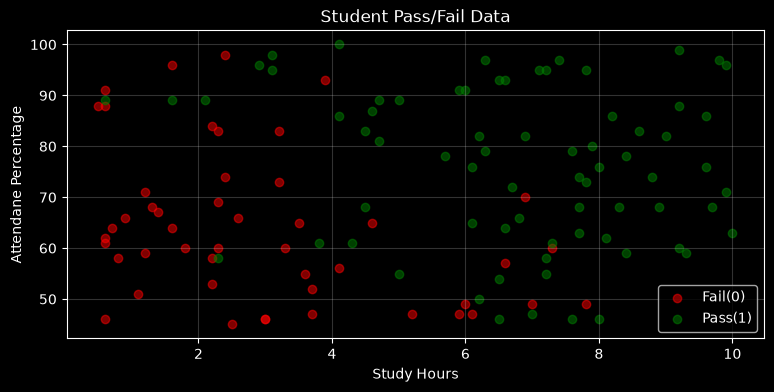

In [206]:

plt.style.use("dark_background")
plt.figure(figsize=(9,4))

fail_students=df[df['Passed']==0]
pass_students=df[df['Passed']==1]



plt.scatter(fail_students['StudyHours'],fail_students['AttendancePercent'],label='Fail(0)',c='r',alpha=0.5)
plt.scatter(pass_students['StudyHours'],pass_students['AttendancePercent'],label='Pass(1)',c='g',alpha=0.5)
plt.xlabel("Study Hours")
plt.ylabel("Attendane Percentage")
plt.title("Student Pass/Fail Data")
plt.legend()
plt.grid(alpha=0.2)


# Logistic Regression

Although its name includes “Regression,” it is mainly used for **classification**.

It converts a linear score into a probability using the sigmoid function:

$$
P(y=1) = \frac{1}{1+e^{-z}}
$$

where:

$$
z = b_0 + b_1x_1 + b_2x_2
$$

The sigmoid always produces a value between `0` and `1`.

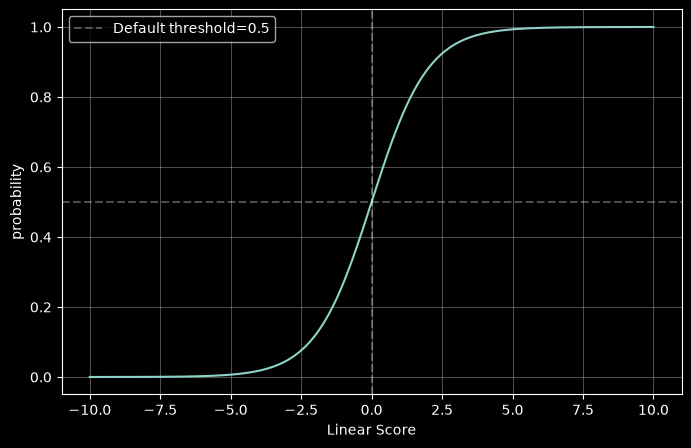

In [207]:
# z is not the exact exam degree it the result of logistic equation after get the true weight and bias to this equation 
#if the score 90 of 100 it will be for example z=8 which will give me prob 0.9997
def sigmoid(z):
    return 1/(1+np.exp(-z))

z_values=np.linspace(-10,10,300)
probabilities=sigmoid(z_values)

plt.figure(figsize=(8,5))
plt.plot(z_values,probabilities)
plt.axhline(0.5,ls='--',label='Default threshold=0.5',alpha=0.3)
plt.axvline(0,ls='--',alpha=0.3)# when z=0 sigmoid give prob 0.5
plt.xlabel("Linear Score")
plt.ylabel("probability")
plt.legend()
plt.grid(alpha=0.3)


### Important interpretation

- A large positive `z` gives a probability close to 1.
- A large negative `z` gives a probability close to 0.
- At `z = 0`, the probability is 0.5.

# Define Features and Target

In [208]:
x=df[['StudyHours','AttendancePercent']]
y=df['Passed']
# y=y.values.reshape(-1,1)

print(x.shape)
print(y.shape)

(120, 2)
(120,)


# Split Into Training And Testing Sets
We use `stratify=y` so both sets preserve approximately the same class proportions.

In [209]:

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42,stratify=y)

print("Training Samples :",len(x_train))
print("Testing Samples :",len(x_test))
print("Training Class Distribution:\n")
print(y_train.value_counts(normalize=True).sort_index())

Training Samples : 90
Testing Samples : 30
Training Class Distribution:

Passed
0   0.400
1   0.600
Name: proportion, dtype: float64


# Scale The Features 
The two features have different scales:

- Study hours are roughly between 0 and 10.
- Attendance is roughly between 45 and 100.

Scaling helps the optimization process and makes coefficients easier to compare.

<details>
<summary><strong>Feature Scaling with StandardScaler</strong></summary>

## Before Scaling (Different Feature Scales)

Example:

| Feature | Range |
|---------|------:|
| StudyHours | 1 - 10 |
| Income | 20,000 - 200,000 |

### Problems

- Features have very different scales.
- Large-scale features can dominate the optimization process.
- Gradient Descent converges more slowly.
- Optimization may zigzag and become less stable.
- Model coefficients are difficult to compare because features have different units.

---

## After Scaling (StandardScaler)

StandardScaler transforms each feature to:

- Mean ≈ 0
- Standard Deviation ≈ 1

Example:

| Feature | Before | After |
|---------|--------|-------|
| StudyHours | 1 - 10 | ≈ -2 to 2 |
| Income | 20,000 - 200,000 | ≈ -2 to 2 |

### Advantages

- All features are on a similar scale.
- Faster convergence during Gradient Descent.
- More stable optimization.
- No feature dominates simply because of its larger values.
- Coefficients become easier to compare since all features are measured in standard deviations.

> **Note:** StandardScaler usually improves the training process, but it does **not guarantee** higher model accuracy.

</details>

In [210]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
# We fit only on the training data because the model should not learn anything from the test data
x_test_scaled=scaler.transform(x_test)

# Train the Logistic Regression Model

In [211]:
model=LogisticRegression()
model.fit(x_train_scaled,y_train)
print("Model Training completed")


Model Training completed


# Inspect The Coefficients

In [212]:
coefficeient_table=pd.DataFrame({
    "Feature":x.columns,
    "Cofficient":model.coef_[0]
})
print(coefficeient_table)
print("\n",model.coef_.shape)

             Feature  Cofficient
0         StudyHours       2.234
1  AttendancePercent       1.127

 (1, 2)


# Predict Probabilities
`predict_proba()` returns two probabilities for every student:

- Probability of class 0: Fail.
- Probability of class 1: Pass.

The two probabilities sum to 1.

In [213]:
probability_pred=model.predict_proba(x_test_scaled)

probability_table=pd.DataFrame({
    "pass_prob":probability_pred[:,0],
    "Fail_prob":probability_pred[:,1]
})
print(probability_table.head(10))

   pass_prob  Fail_prob
0      0.031      0.969
1      0.016      0.984
2      0.380      0.620
3      0.935      0.065
4      0.915      0.085
5      0.340      0.660
6      0.976      0.024
7      0.040      0.960
8      0.965      0.035
9      0.019      0.981


# Convert Probability To Classes

In [214]:
pass_prob=probability_pred[:,1]

manual_pred=(pass_prob>=0.5).astype(int)
model_pred=model.predict(x_test_scaled)

print("Manual Prediction is it equal to model.predict() ?? :",np.array_equal(manual_pred,model_pred))

Manual Prediction is it equal to model.predict() ?? : True


# Compare Actual and Predicted Results

In [215]:
# reset index create a new sequential index instead of 5,77,9,43 -> 0,1,2,3 and two index are kept old and new
# drop = True means the old index columns is not kept 
# copy means create a new independent dataframe
results=x_test.reset_index(drop=True).copy()
results['Actual']=y_test.reset_index(drop=True)
results['PassProbability']=pass_prob
results["Predicted"]=model_pred
results['Correct']= results['Actual']==results['Predicted']
print(results.head(10))

   StudyHours  AttendancePercent  Actual  PassProbability  Predicted  Correct
0       8.900                 68       1            0.969          1     True
1       9.700                 68       1            0.984          1     True
2       7.000                 47       1            0.620          1     True
3       1.600                 64       0            0.065          0     True
4       2.300                 60       0            0.085          0     True
5       3.100                 95       1            0.660          1     True
6       0.800                 58       0            0.024          0     True
7       7.600                 79       1            0.960          1     True
8       1.200                 59       0            0.035          0     True
9       7.200                 95       1            0.981          1     True


# Evaluate The Classifier

### Metric meanings

- **Accuracy:** Overall percentage of correct predictions.
- **Precision:** Of the students predicted to pass, how many actually passed?
- **Recall:** Of the students who actually passed, how many did the model detect?
- **F1-score:** A balance between precision and recall.


In [216]:
accuracy=accuracy_score(y_test,model_pred)# from all prediction what is  correct
#If you encounter a division by zero, don't raise a warning. Just return 0.
precision=precision_score(y_test,model_pred,zero_division=0)
recall=recall_score(y_test,model_pred,zero_division=0)
f1=f1_score(y_test,model_pred,zero_division=0) 

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

Accuracy : 0.833
Precision : 0.933
Recall : 0.778
F1 Score : 0.848


# Confusion Matrix

True Negative : 11
True Positive : 14
False Negative : 4
False Postive : 1
14


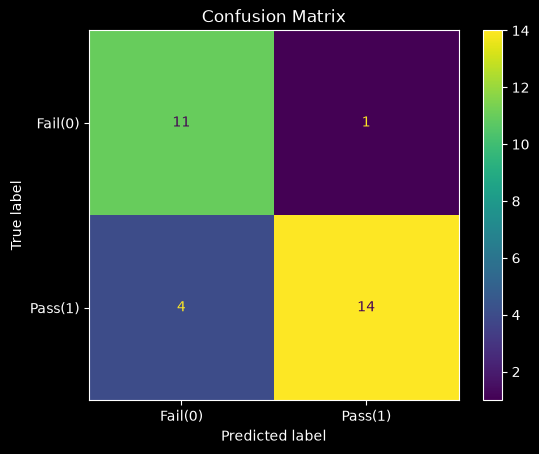

In [217]:
cm=confusion_matrix(y_test,model_pred)
labels=["Fail(0)","Pass(1)"]

disp=ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Confusion Matrix")
tn,fp,fn,tp=cm.ravel()

print("True Negative :",tn)
print("True Positive :",tp)
print("False Negative :",fn)
print("False Postive :",fp)

print(len(results[(results['Actual'] == 1) & (results['Predicted'] == 1)]))


# Classification Report

In [218]:

print(classification_report(y_test,model_pred,target_names=["Fail","Pass"],zero_division=0))

# Support Total Number Of Samples For Each Row 
# Macro Average Treat every Class equally
# Weighted Avg care about the number of samples in each class 

              precision    recall  f1-score   support

        Fail       0.73      0.92      0.81        12
        Pass       0.93      0.78      0.85        18

    accuracy                           0.83        30
   macro avg       0.83      0.85      0.83        30
weighted avg       0.85      0.83      0.84        30



# Visualize the decision boundary

The model separates the feature space into:

- A region predicted as Fail.
- A region predicted as Pass.

The boundary corresponds approximately to a predicted probability of 0.5.

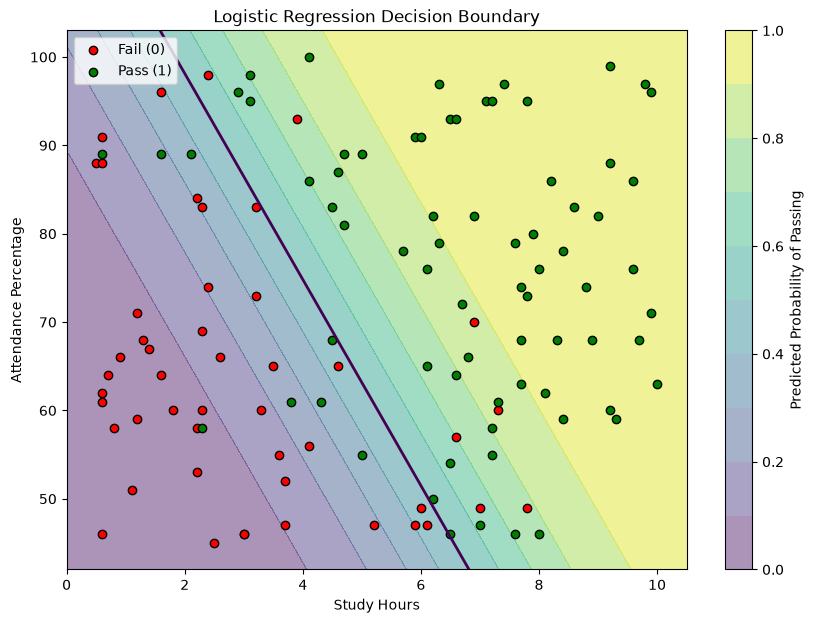

In [237]:
plt.style.use("default")
# "For every possible combination of Study Hours and Attendance, what would the model predict?" 

#To leave a little empty space around the graph so the points don't touch the edges
hours_min, hours_max = df["StudyHours"].min() - 0.5, df["StudyHours"].max() + 0.5
attendance_min, attendance_max = (
    df["AttendancePercent"].min() - 3,
    df["AttendancePercent"].max() + 3
)

# we want to create more and more of points that help me color the entire graph , not just the original students
hours_grid, attendance_grid = np.meshgrid(
    np.linspace(hours_min, hours_max, 250),
    np.linspace(attendance_min, attendance_max, 250)
)

# change matrix to one long column
grid_df=pd.DataFrame({
    "StudyHours":hours_grid.ravel(),
     "AttendancePercent": attendance_grid.ravel()
})

# we use transform only -> we want to use the same scaling learned from the training data.
grid_scaled = scaler.transform(grid_df)
grid_probability = model.predict_proba(grid_scaled)[:,1]# Pass Probability
# The probabilities are one long list , But the graph expects a matrix
probability_surface=grid_probability.reshape(hours_grid.shape) 

plt.figure(figsize=(10, 7))
contour = plt.contourf(
    hours_grid,
    attendance_grid,
    probability_surface,
    levels=np.linspace(0, 1, 11),
    alpha=0.45
)
plt.colorbar(contour, label="Predicted Probability of Passing")

plt.contour(
    hours_grid,
    attendance_grid,
    probability_surface,
    levels=[0.5],
    linewidths=2
)

plt.scatter(
    fail_students["StudyHours"],
    fail_students["AttendancePercent"],
    label="Fail (0)",
    c='r',
    edgecolors="black"
)
plt.scatter(
    pass_students["StudyHours"],
    pass_students["AttendancePercent"],
    label="Pass (1)",
    c='g',
    edgecolors="black"
)


plt.xlabel("Study Hours")
plt.ylabel("Attendance Percentage")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

# Predict New Students

In [ ]:
new_students=pd.DataFrame({
    'StudyHours':[2.0,5.0,8.0],
    'AttendancePercent':[55,75,92]
})

new_students_scalled=scaler.transform(new_students)
new_pass_prob=model.predict_proba(new_students_scalled)[:,1]
new_model_pred=model.predict(new_students_scalled)

results=new_students.copy()
results['PassProbability']=new_pass_prob
results['PredictedClass']=new_model_pred
results['PredictedLabel']=results['PredictedClass'].map({0:"Fail",1:"Pass"})
print(results.to_string())

   StudyHours  AttendancePercent  PassProbability  PredictedClass PredictedLabel
0       2.000                 55            0.049               0           Fail
1       5.000                 75            0.693               1           Pass
2       8.000                 92            0.988               1           Pass


# How does Changing the threshold affect predictions ?


In [ ]:
thresholds = [0.30, 0.50, 0.70]

thresholds_comparsion=pd.DataFrame({
    "Actual":y_test.reset_index(drop=True),
    "PassProbability":pass_prob
})

for threshold in thresholds:
    thresholds_comparsion[f"Prediction_at_{threshold}"]=(thresholds_comparsion['PassProbability']>=threshold).astype(int)
print(thresholds_comparsion.head(15).to_string())    

    Actual  PassProbability  Prediction_at_0.3  Prediction_at_0.5  Prediction_at_0.7
0        1            0.969                  1                  1                  1
1        1            0.984                  1                  1                  1
2        1            0.620                  1                  1                  0
3        0            0.065                  0                  0                  0
4        0            0.085                  0                  0                  0
5        1            0.660                  1                  1                  0
6        0            0.024                  0                  0                  0
7        1            0.960                  1                  1                  1
8        0            0.035                  0                  0                  0
9        1            0.981                  1                  1                  1
10       1            0.075                  0                  0